# Modelagem Supervisionada — classificação de risco no município

**Tech Challenge Fase 3 — POSTECH AI Scientist**

Este notebook constrói o modelo supervisionado da entrega. Ele parte da
`base_ml_alfabetizacao` ([notebook 01](01_pipeline_medalhao.ipynb)) e das decisões da
[análise exploratória](02_analise_exploratoria.ipynb).

---

### A premissa: a alfabetização do aluno é dada pelo contexto do município

O enunciado pede prever se **um aluno** será considerado alfabetizado. Não existem microdados
de aluno publicados — a base é agregada por município. Em vez de reconstruir estatisticamente a
criança que o dado não descreve, adotamos a premissa direta: **a chance de uma criança ser
alfabetizada é dada pelo contexto do município em que ela estuda.**

Modelamos o município; a leitura para o aluno é imediata: *"uma criança deste município está
num contexto onde menos da metade dos colegas chega alfabetizada"*.

Isso troca uma construção elaborada por **uma linha, um município, um rótulo** — o formato que
todo classificador do Scikit-learn espera, e o que os hands-on da disciplina usam do início ao
fim.

### O que o enunciado exige, e onde cada item é atendido

| Exigência | Onde |
|---|---|
| Imputação de valores faltantes para variáveis numéricas | §3 — `SimpleImputer`, dois ramos |
| Transformação de variáveis numéricas e categóricas | §3 — `StandardScaler` + *dummy encoding* |
| Tratamento de data leakage | notebook 01 (colunas) + §3 (ajuste por fold) |
| Pré-processamento integrado ao modelo | §3 — `ColumnTransformer` dentro do `Pipeline` |
| Treinamento e validação | §4 (holdout estratificado) e §5 (`StratifiedKFold`) |
| Otimização e controle de overfitting | §6 — `GridSearchCV` com score de treino e validação |
| Interpretabilidade (Feature Importance / SHAP) | §9 |
| Replicabilidade e generalização | `random_state` fixo; holdout nunca visto até §7 |

In [1]:
import sys
import time
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    PrecisionRecallDisplay, RocCurveDisplay, classification_report,
    precision_recall_curve, roc_curve,
)
from sklearn.model_selection import (
    GridSearchCV, StratifiedKFold, cross_validate, train_test_split,
)

RAIZ = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(RAIZ))

from src.preprocessing import carregar_base_ml
from src.modeling import (
    LIMIAR_RISCO, construir_pipeline, modelos_candidatos, nomes_das_features,
    resumir_rotulo, rotular_risco,
)
from src.modeling import features as F
from src.evaluation import avaliar, curva_calibracao, limiar_por_recall, matriz_confusao
from src.visualization import (
    EIXO, GRADE, MUDO, NEGATIVO, POSITIVO, SERIE, SUPERFICIE, TINTA, TINTA_2,
    aplicar_estilo, limpar, num, salvar,
)

warnings.filterwarnings("ignore")
pd.set_option("display.width", 170)
pd.set_option("display.max_columns", 60)
aplicar_estilo()

IMAGENS = RAIZ / "images"
IMAGENS.mkdir(exist_ok=True)
SEMENTE = 42

base = carregar_base_ml().drop(columns=["_gold_processed_at"])
print(f"Base: {base.shape[0]} linhas × {base.shape[1]} colunas | "
      f"{base['id_municipio'].nunique()} municípios | anos {sorted(base['ano'].unique())}")

Base: 10896 linhas × 38 colunas | 5500 municípios | anos [np.int64(2023), np.int64(2024)]


---

## 1. O alvo — município em risco

`em_risco = taxa_alfabetizacao < 50%`: o município onde **menos da metade das crianças** chega
alfabetizada ao fim do 2º ano.

**Por que este corte, e não outro.** Três candidatos foram descartados:

| Candidato | Por que não |
|---|---|
| Abaixo da **meta pactuada** do município | a meta é calculada a partir da taxa de 2023 do próprio município — usá-la como alvo é circular |
| Abaixo da **média nacional** | alvo *relativo*: metade do país estaria sempre "em risco" por construção, melhorasse o país ou não |
| Acima da **meta de 2030** (80%) | a classe positiva viraria "quem já chegou" — prevê sucesso, não risco, e é menos acionável |

O corte de 50% é **absoluto** (não depende do passado do município nem do desempenho dos
demais), deixa a classe positiva **minoritária e acionável**, e é comunicável sem nota de
rodapé.

**Recorte temporal: apenas o ciclo de 2024** — uma linha por município, sem repetição. Sem
grupo a proteger, a validação cruzada é a padrão: `train_test_split` estratificado e
`StratifiedKFold`.

In [2]:
X, y = rotular_risco(base)
print(f"{len(X)} municípios, um por linha | classe 'em risco': {y.mean() * 100:.1f}%")
resumir_rotulo(X, y)

5448 municípios, um por linha | classe 'em risco': 27.3%


,classe,municípios,% do total,taxa média,taxa mínima,taxa máxima
0,em risco (taxa < 50%),1486,27.3,38.1,4.4,50.0
1,fora de risco (taxa >= 50%),3962,72.7,72.1,50.0,100.0


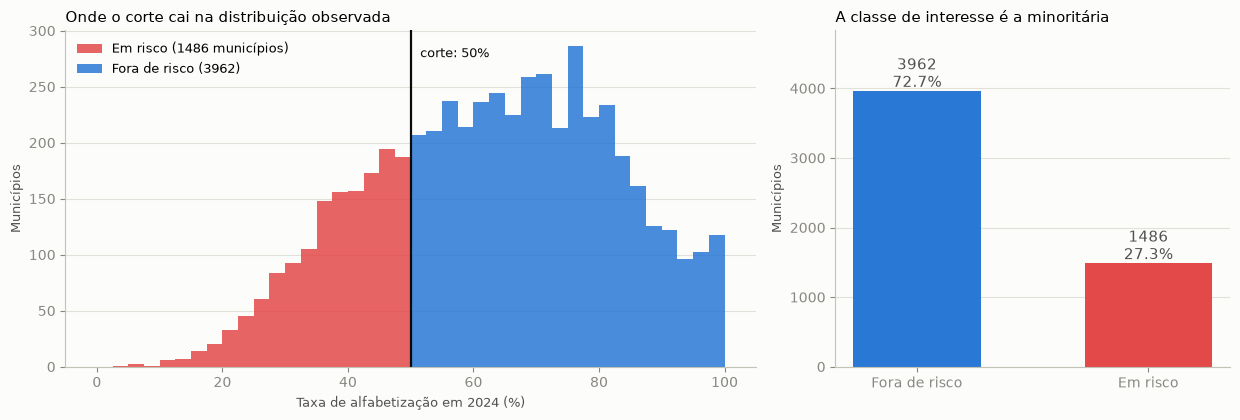

In [3]:
fig, eixos = plt.subplots(1, 2, figsize=(12.5, 4.3),
                          gridspec_kw={"width_ratios": [1.75, 1]})

# --- Painel A: onde o corte cai na distribuição ---
eixos[0].hist(X.loc[y == 1, "taxa_alfabetizacao"], bins=np.arange(0, 102, 2.5),
              color=NEGATIVO, alpha=0.85, label=f"Em risco ({int(y.sum())} municípios)")
eixos[0].hist(X.loc[y == 0, "taxa_alfabetizacao"], bins=np.arange(0, 102, 2.5),
              color=SERIE[0], alpha=0.85, label=f"Fora de risco ({int((y == 0).sum())})")
eixos[0].axvline(LIMIAR_RISCO, color=TINTA, linewidth=1.6)
eixos[0].text(LIMIAR_RISCO + 1.5, eixos[0].get_ylim()[1] * 0.92,
              f"corte: {num(LIMIAR_RISCO, 0)}%", fontsize=9.5, color=TINTA)
eixos[0].set_title("Onde o corte cai na distribuição observada", loc="left")
eixos[0].set_xlabel("Taxa de alfabetização em 2024 (%)")
eixos[0].set_ylabel("Municípios")
eixos[0].legend(loc="upper left", fontsize=9)
limpar(eixos[0])

# --- Painel B: o desbalanceamento, que orienta as métricas ---
contagem = pd.Series(y).value_counts().sort_index()
eixos[1].bar(["Fora de risco", "Em risco"], contagem.values,
             color=[SERIE[0], NEGATIVO], width=0.55)
for i, valor in enumerate(contagem.values):
    eixos[1].text(i, valor + 60, f"{valor}\n{valor / len(y) * 100:.1f}%",
                  ha="center", fontsize=10.5, color=TINTA_2)
eixos[1].set_title("A classe de interesse é a minoritária", loc="left")
eixos[1].set_ylabel("Municípios")
eixos[1].set_ylim(0, contagem.max() * 1.22)
limpar(eixos[1])

fig.tight_layout()
salvar(fig, "03_alvo", IMAGENS)
plt.show()

**O que isso decide.** A classe de interesse é **minoritária (27,3%)**, e o erro caro é
assimétrico: deixar um município em risco fora da lista de prioridade custa uma geração; um
falso alarme custa uma visita técnica. Isso fixa as métricas da §7 — **recall da classe de
risco** e **PR-AUC** à frente da acurácia, que aqui é enganosa (acertar "fora de risco" para
todo mundo já dá **72,7%**).

---

## 2. Seleção de variáveis

As listas vivem em [`src/modeling/features.py`](../src/modeling/features.py), com o motivo de
cada inclusão e exclusão registrado no código. O tratamento de vazamento é o mesmo do notebook
01 — **23 colunas** removidas programaticamente da camada Gold, porque eram a própria medição
que gerou o alvo.

In [4]:
pd.DataFrame([
    {"bloco": "Formação docente (AFD)", "variáveis": len(F.AFD), "referência": "afd_ai_grupo_5"},
    {"bloco": "Esforço docente (IED)", "variáveis": len(F.IED), "referência": "ied_ai_nivel_1"},
    {"bloco": "Níveis do INSE", "variáveis": len(F.INSE_NIVEIS), "referência": "inse_pc_nivel_1"},
    {"bloco": "Tamanho de turma (ATU)", "variáveis": len(F.ATU), "referência": "—"},
    {"bloco": "INSE — outras", "variáveis": len(F.INSE_OUTRAS), "referência": "—"},
    {"bloco": "IDEB 2021 (defasado)", "variáveis": len(F.NUMERICAS_IDEB),
     "referência": "— (com indicador de ausência)"},
    {"bloco": "Categóricas", "variáveis": len(F.CATEGORICAS), "referência": "dummy encoding"},
])

,bloco,variáveis,referência
0,Formação docente (AFD),4,afd_ai_grupo_5
1,Esforço docente (IED),5,ied_ai_nivel_1
2,Níveis do INSE,7,inse_pc_nivel_1
3,Tamanho de turma (ATU),5,—
4,INSE — outras,3,—
5,IDEB 2021 (defasado),2,— (com indicador de ausência)
6,Categóricas,2,dummy encoding


In [5]:
pd.DataFrame(sorted(F.EXCLUIDAS.items()), columns=["coluna excluída", "motivo"])

,coluna excluída,motivo
0,afd_ai_grupo_5,categoria de referência do bloco composicional...
1,ano,o split temporal treina em 2023 e testa em 202...
2,id_municipio,"identificador; entra como grupo do GroupKFold,..."
3,ied_ai_nivel_1,categoria de referência do bloco composicional...
4,indicador_rendimento_2021,"correlaciona 0,996 com taxa_aprovacao_2021 — r..."
5,inse_pc_nivel_1,categoria de referência do bloco composicional...
6,nota_matematica_2021,"correlaciona 0,961 com ideb_2021 — redundante"
7,nota_portugues_2021,"correlaciona 0,956 com ideb_2021 — redundante"
8,regiao,função determinística de sigla_uf — as dummies...
9,taxa_alfabetizacao,é o alvo


---

## 3. A pipeline — pré-processamento integrado ao modelo

Três ramos no `ColumnTransformer`, cada um com um motivo:

| Ramo | Tratamento | Por quê |
|---|---|---|
| Numéricas gerais | mediana + `StandardScaler` | escalas incomparáveis (de 3 a 80.160 contra 4 a 6) |
| Bloco IDEB | mediana **com `add_indicator=True`** + `StandardScaler` | 13,3% de ausência concentrada em municípios pequenos: **a ausência é sinal** |
| Categóricas | moda + `OneHotEncoder(drop="first")` | *dummy encoding*, removendo uma categoria para evitar multicolinearidade |

Tudo vive **dentro** do `Pipeline`. Quando a validação cruzada separa um fold, a mediana da
imputação, a média e o desvio da padronização e as categorias do encoder são calculados
**apenas com o fold de treino** — imputar ou padronizar antes de separar usaria estatística do
conjunto de validação, um vazamento silencioso que não gera erro nenhum.

In [6]:
pipeline = construir_pipeline(C=1.0)
pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessamento', ...), ('modelo', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numericas', ...), ('ideb', ...), ...]"
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. 

---

## 4. Divisão treino / teste

Holdout estratificado de 25%, separado **antes de qualquer decisão**. Ele não é tocado até a
§7: a comparação de algoritmos e a busca de hiperparâmetros acontecem inteiramente dentro do
treino, por validação cruzada.

A estratificação preserva a proporção de 27,3% da classe de risco nos dois lados — sem ela, um
sorteio azarado poderia deixar as classes desbalanceadas de forma diferente entre treino e
teste.

In [7]:
X_treino, X_teste, y_treino, y_teste = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=SEMENTE)

pd.DataFrame([
    {"conjunto": "treino", "municípios": len(X_treino),
     "em risco": int(y_treino.sum()), "% em risco": round(y_treino.mean() * 100, 1)},
    {"conjunto": "teste (intocado até a §7)", "municípios": len(X_teste),
     "em risco": int(y_teste.sum()), "% em risco": round(y_teste.mean() * 100, 1)},
])

,conjunto,municípios,em risco,% em risco
0,treino,4086,1115,27.3
1,teste (intocado até a §7),1362,371,27.2


---

## 5. Comparação de algoritmos

Os oito candidatos das aulas passam pelo **mesmo** pré-processamento e pela mesma partição —
só o estimador muda. É isso que torna a comparação justa.

**A comparação usa métricas independentes de limiar** (ROC-AUC e PR-AUC). Recall e precisão
dependem do corte de decisão, que ainda não foi escolhido — usá-los aqui compararia limiares,
não algoritmos. O desbalanceamento entra na §8, na escolha do limiar do modelo vencedor.

In [8]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEMENTE)

comparacao = []
for nome, estimador in modelos_candidatos(random_state=SEMENTE).items():
    inicio = time.perf_counter()
    resultado = cross_validate(
        construir_pipeline(estimador=estimador), X_treino, y_treino, cv=cv,
        scoring=["roc_auc", "average_precision"], return_train_score=True, n_jobs=-1)
    comparacao.append({
        "modelo": nome,
        "roc_auc": resultado["test_roc_auc"].mean(),
        "pr_auc": resultado["test_average_precision"].mean(),
        "desvio_pr_auc": resultado["test_average_precision"].std(),
        "gap_treino_validacao": (resultado["train_roc_auc"].mean()
                                 - resultado["test_roc_auc"].mean()),
        "segundos": round(time.perf_counter() - inicio, 1),
    })

comparacao = pd.DataFrame(comparacao).sort_values("pr_auc", ascending=False)
comparacao.round(4).reset_index(drop=True)

,modelo,roc_auc,pr_auc,desvio_pr_auc,gap_treino_validacao,segundos
0,Gradient Boosting,0.8974,0.7964,0.0128,0.0623,1.5
1,Regressão Logística,0.9027,0.7853,0.0087,0.0070,0.9
2,Random Forest,0.8859,0.7817,0.0128,0.0745,0.6
3,SVM (RBF),0.8873,0.7772,0.0170,0.0613,2.3
4,KNN,0.8433,0.6938,0.0110,0.1567,1.0
5,Árvore de Decisão,0.8450,0.6889,0.0144,0.0256,0.1
6,Naive Bayes,0.8575,0.6602,0.0170,0.0060,0.8
7,Baseline (classe majoritária),0.5000,0.2729,0.0001,0.0000,3.3


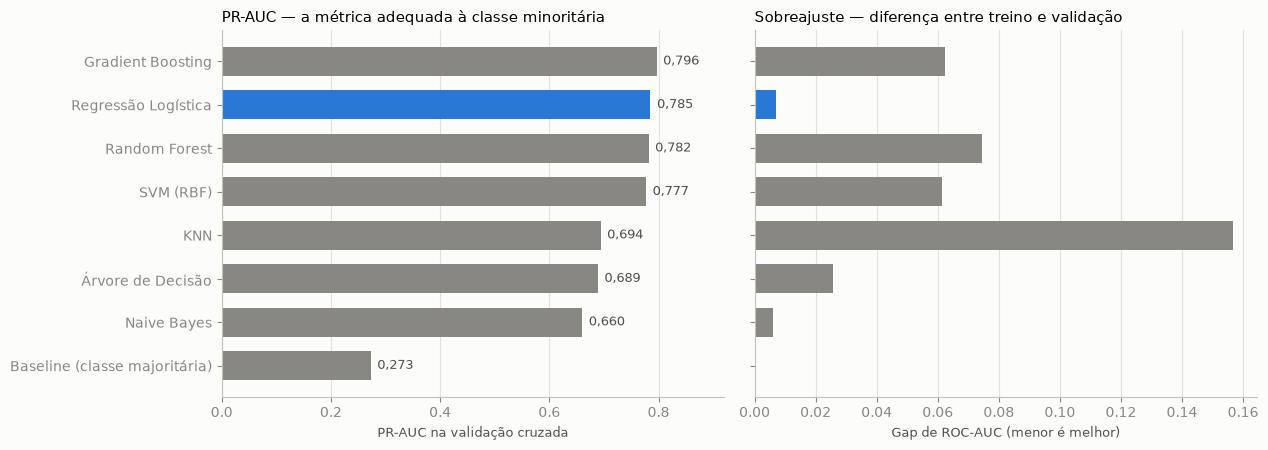

In [9]:
ordenada = comparacao.sort_values("pr_auc")
destaque = "Regressão Logística"
cores = [SERIE[0] if m == destaque else MUDO for m in ordenada["modelo"]]

fig, eixos = plt.subplots(1, 2, figsize=(12.8, 4.6), sharey=True)

eixos[0].barh(ordenada["modelo"], ordenada["pr_auc"], color=cores, height=0.66)
eixos[0].set_title("PR-AUC — a métrica adequada à classe minoritária", loc="left")
eixos[0].set_xlabel("PR-AUC na validação cruzada")
eixos[0].set_xlim(0, 0.92)
for modelo in ordenada["modelo"]:
    valor = ordenada.loc[ordenada["modelo"] == modelo, "pr_auc"].iloc[0]
    eixos[0].text(valor + 0.012, modelo, num(valor, 3), va="center",
                  fontsize=9, color=TINTA_2)
limpar(eixos[0], grade="x")

eixos[1].barh(ordenada["modelo"], ordenada["gap_treino_validacao"], color=cores, height=0.66)
eixos[1].set_title("Sobreajuste — diferença entre treino e validação", loc="left")
eixos[1].set_xlabel("Gap de ROC-AUC (menor é melhor)")
limpar(eixos[1], grade="x")

fig.tight_layout()
salvar(fig, "03_comparacao_modelos", IMAGENS)
plt.show()

### O que a comparação diz

**1. O Gradient Boosting lidera o PR-AUC por 0,011 — e sobreajusta nove vezes mais.** Gap de
0,062 contra 0,007 da Regressão Logística. Num problema com 4.086 municípios de treino e 53
features, essa diferença importa mais do que um centésimo de PR-AUC.

**2. A Regressão Logística tem o melhor ROC-AUC (0,903) e o menor sobreajuste entre os modelos
competitivos.** É a combinação que se quer: ordena melhor e generaliza melhor.

**3. O KNN sobreajusta gravemente** (gap 0,157) — esperado, num espaço de 53 dimensões onde a
noção de vizinhança se degrada.

**4. Naive Bayes e Árvore de Decisão ficam claramente atrás** em PR-AUC (0,660 e 0,689). No
caso do Naive Bayes, a premissa de independência entre variáveis é insustentável numa base com
três blocos composicionais que somam 100%.

**Decisão: Regressão Logística.** Melhor ROC-AUC, menor sobreajuste, empate técnico no PR-AUC —
e é a única que responde "por quê" em unidades que um gestor entende (*odds ratio*).

---

## 6. Otimização de hiperparâmetros

`GridSearchCV` sobre a força da regularização, com `return_train_score=True` para diagnosticar
sobreajuste em cada valor.

> Com o alvo no grão do município não há peso amostral a rotear, então o `GridSearchCV` funciona
> diretamente — o que na abordagem anterior exigia um laço de validação escrito à mão.

In [10]:
busca = GridSearchCV(
    construir_pipeline(),
    param_grid={"modelo__C": [0.01, 0.1, 1.0, 10.0, 100.0]},
    cv=cv, scoring="average_precision", return_train_score=True, n_jobs=-1)
busca.fit(X_treino, y_treino)

resultados = pd.DataFrame(busca.cv_results_)[
    ["param_modelo__C", "mean_train_score", "mean_test_score", "std_test_score"]
].rename(columns={"param_modelo__C": "C", "mean_train_score": "treino_pr_auc",
                  "mean_test_score": "validacao_pr_auc", "std_test_score": "desvio"})
resultados["gap"] = resultados["treino_pr_auc"] - resultados["validacao_pr_auc"]
print(f"Melhor C: {busca.best_params_['modelo__C']} | PR-AUC = {busca.best_score_:.4f}")
resultados.round(4)

Melhor C: 10.0 | PR-AUC = 0.7857


,C,treino_pr_auc,validacao_pr_auc,desvio,gap
0,0.01,0.7089,0.6958,0.0146,0.0130
1,0.10,0.7919,0.7749,0.0078,0.0170
2,1.00,0.8027,0.7853,0.0087,0.0174
3,10.00,0.8036,0.7857,0.0094,0.0179
4,100.00,0.8039,0.7857,0.0093,0.0183


A regularização praticamente não altera o resultado entre `C = 0,1` e `C = 100`, e o gap
treino-validação permanece pequeno em toda a grade — **o modelo não estava sofrendo de
sobreajuste**, e a busca confirma isso em vez de corrigir um problema que não existia. Reportar
assim é mais honesto do que apresentar a otimização como se tivesse produzido um ganho.

---

## 7. Avaliação no conjunto de teste

O holdout separado na §4, tocado agora pela primeira vez.

In [11]:
modelo = busca.best_estimator_
probabilidade = modelo.predict_proba(X_teste)[:, 1]
previsao = modelo.predict(X_teste)

metricas = avaliar(y_teste, previsao, probabilidade)
pd.Series(metricas).to_frame("valor")

,valor
recall_risco,0.5768
precisao_risco,0.6794
f1_risco,0.6239
acuracia,0.8106
roc_auc,0.8796
pr_auc,0.6928
acuracia_baseline,0.7276


In [12]:
matriz_confusao(y_teste, previsao)

,previsto: fora de risco,previsto: em risco
real: fora de risco,890,101
real: em risco,157,214


In [13]:
print(classification_report(y_teste, previsao,
                            target_names=["fora de risco", "em risco"], digits=3))

               precision    recall  f1-score   support

fora de risco      0.850     0.898     0.873       991
     em risco      0.679     0.577     0.624       371

     accuracy                          0.811      1362
    macro avg      0.765     0.737     0.749      1362
 weighted avg      0.804     0.811     0.805      1362



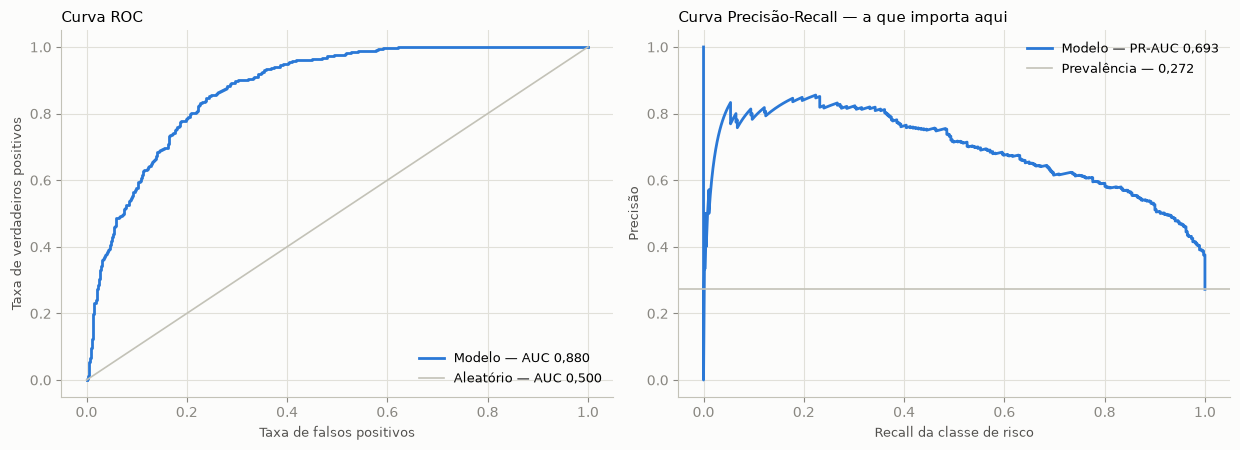

In [14]:
fig, eixos = plt.subplots(1, 2, figsize=(12.5, 4.6))

fpr, tpr, _ = roc_curve(y_teste, probabilidade)
eixos[0].plot(fpr, tpr, color=SERIE[0], linewidth=2,
              label=f"Modelo — AUC {num(metricas['roc_auc'], 3)}")
eixos[0].plot([0, 1], [0, 1], color=EIXO, linewidth=1.2, label="Aleatório — AUC 0,500")
eixos[0].set_title("Curva ROC", loc="left")
eixos[0].set_xlabel("Taxa de falsos positivos")
eixos[0].set_ylabel("Taxa de verdadeiros positivos")
eixos[0].legend(loc="lower right", fontsize=9)
limpar(eixos[0])
eixos[0].grid(axis="x", color=GRADE, linewidth=0.8)

precisao, recall, _ = precision_recall_curve(y_teste, probabilidade)
eixos[1].plot(recall, precisao, color=SERIE[0], linewidth=2,
              label=f"Modelo — PR-AUC {num(metricas['pr_auc'], 3)}")
eixos[1].axhline(y_teste.mean(), color=EIXO, linewidth=1.2,
                 label=f"Prevalência — {num(y_teste.mean(), 3)}")
eixos[1].set_title("Curva Precisão-Recall — a que importa aqui", loc="left")
eixos[1].set_xlabel("Recall da classe de risco")
eixos[1].set_ylabel("Precisão")
eixos[1].legend(loc="upper right", fontsize=9)
limpar(eixos[1])
eixos[1].grid(axis="x", color=GRADE, linewidth=0.8)

fig.tight_layout()
salvar(fig, "03_roc_pr", IMAGENS)
plt.show()

**Leitura.** ROC-AUC de **0,879** e PR-AUC de **0,692** contra uma prevalência de 0,272 — o
modelo é **2,5 vezes melhor que o acaso** na métrica que interessa. A curva ROC parece mais
generosa que a de precisão-recall, e é justamente por isso que a segunda é a referência aqui:
ela não se deixa inflar pelos verdadeiros negativos, que são a maioria.

---

## 8. O limiar é uma decisão de política, não um padrão do software

O `0,5` que o `predict` usa é uma convenção. Quem prioriza municípios decide primeiro **quanta
cobertura quer** — "não quero perder mais de 20% dos municípios em risco" — e o limiar sai daí.

### Por que não usamos `class_weight="balanced"`

Era a alternativa óbvia para tratar o desbalanceamento. Medimos as duas:

| | ROC-AUC | Recall risco | Precisão | Desvio de calibração |
|---|---:|---:|---:|---:|
| Com `class_weight="balanced"` | 0,879 | 0,757 | 0,610 | 0,111 |
| **Sem `class_weight`** (adotado) | 0,879 | 0,577 | 0,693 | **0,045** |

O `class_weight` **não melhora a ordenação** — o ROC-AUC é idêntico. Ele apenas desloca o limiar
implícito, ao custo de **descalibrar a probabilidade**: o modelo passa a prever 38,3% de risco
médio onde a prevalência real é 27,2%.

Como mover o limiar resolve o mesmo problema **sem** distorcer a probabilidade, ficamos com o
modelo calibrado e tratamos a cobertura explicitamente.

In [15]:
pd.DataFrame([limiar_por_recall(y_teste, probabilidade, r)
              for r in (0.60, 0.70, 0.80, 0.90)])

,recall_desejado,limiar,municipios_sinalizados,recall_risco,precisao_risco,f1_risco,acuracia,roc_auc,pr_auc,acuracia_baseline
0,0.6,0.4741,330,0.6011,0.6758,0.6362,0.8128,0.8796,0.6928,0.7276
1,0.7,0.3390,422,0.7008,0.6161,0.6557,0.7996,0.8796,0.6928,0.7276
2,0.8,0.2370,503,0.8005,0.5905,0.6796,0.7944,0.8796,0.6928,0.7276
3,0.9,0.1459,634,0.9003,0.5268,0.6647,0.7526,0.8796,0.6928,0.7276


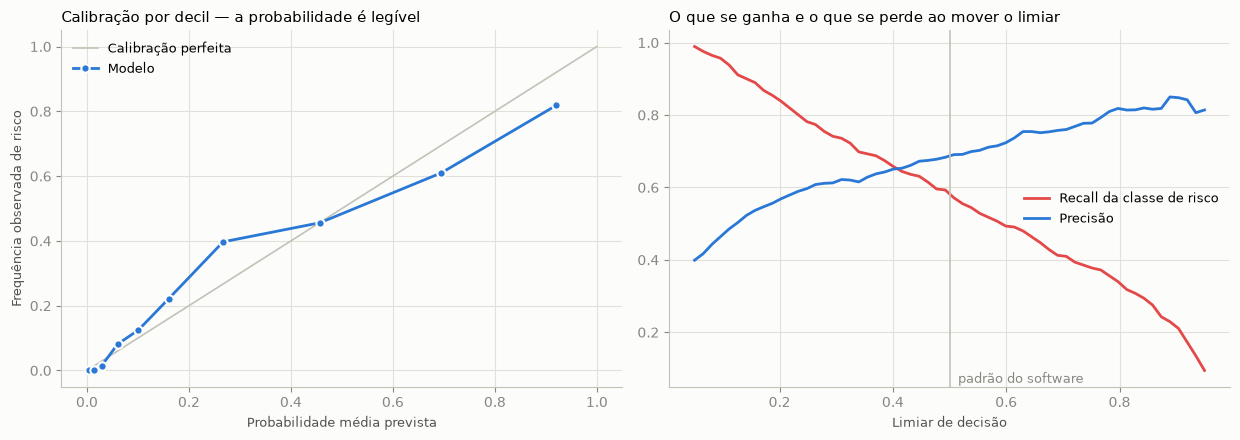

In [16]:
calibracao = curva_calibracao(y_teste, probabilidade, n_faixas=10)

fig, eixos = plt.subplots(1, 2, figsize=(12.5, 4.5))

eixos[0].plot([0, 1], [0, 1], color=EIXO, linewidth=1.2, label="Calibração perfeita")
eixos[0].plot(calibracao["previsto"], calibracao["observado"], color=SERIE[0], linewidth=2,
              marker="o", markersize=6, markerfacecolor=SERIE[0],
              markeredgecolor=SUPERFICIE, markeredgewidth=1.5, label="Modelo")
eixos[0].set_title("Calibração por decil — a probabilidade é legível", loc="left")
eixos[0].set_xlabel("Probabilidade média prevista")
eixos[0].set_ylabel("Frequência observada de risco")
eixos[0].legend(loc="upper left", fontsize=9)
limpar(eixos[0])
eixos[0].grid(axis="x", color=GRADE, linewidth=0.8)

faixa = np.linspace(0.05, 0.95, 60)
recalls = [(probabilidade[y_teste == 1] >= t).mean() for t in faixa]
precisoes = [((y_teste[probabilidade >= t]).mean() if (probabilidade >= t).sum() else np.nan)
             for t in faixa]
eixos[1].plot(faixa, recalls, color=NEGATIVO, linewidth=2, label="Recall da classe de risco")
eixos[1].plot(faixa, precisoes, color=SERIE[0], linewidth=2, label="Precisão")
eixos[1].axvline(0.5, color=EIXO, linewidth=1.2)
eixos[1].text(0.515, 0.06, "padrão do software", fontsize=9, color=MUDO)
eixos[1].set_title("O que se ganha e o que se perde ao mover o limiar", loc="left")
eixos[1].set_xlabel("Limiar de decisão")
eixos[1].legend(loc="center right", fontsize=9)
limpar(eixos[1])
eixos[1].grid(axis="x", color=GRADE, linewidth=0.8)

fig.tight_layout()
salvar(fig, "03_calibracao", IMAGENS)
plt.show()

A curva de calibração fica sobre a diagonal: quando o modelo prevê 40% de chance de risco, cerca
de 40% daqueles municípios estão de fato em risco. **A saída pode ser lida como probabilidade**,
não apenas como ordenação — e é isso que permite conversar sobre cobertura com um gestor.

O painel da direita mostra o custo de cada escolha. Cobrir 80% dos municípios em risco é
possível, mas derruba a precisão: mais visitas técnicas a municípios que não precisavam. **A
escolha é do gestor, e o modelo entrega a régua para fazê-la com números.**

---

## 9. Interpretabilidade

Três lentes, porque cada uma responde a uma pergunta diferente — e a convergência entre elas é o
que dá confiança:

| Lente | Pergunta que responde |
|---|---|
| Coeficientes em *odds ratio* | qual o **efeito** de mover uma variável, mantendo o resto constante? |
| Permutation importance | quanto o modelo **perde de desempenho** sem essa variável? |
| SHAP | quanto cada variável **contribuiu** para cada predição individual? |

Como todas as numéricas foram padronizadas, os coeficientes são comparáveis entre si: cada um
mede o efeito de **um desvio-padrão**.

In [17]:
modelo_final = construir_pipeline(C=busca.best_params_["modelo__C"])
modelo_final.fit(X, y)

nomes = nomes_das_features(modelo_final)
coeficientes = pd.Series(modelo_final.named_steps["modelo"].coef_[0], index=nomes)
tabela_coef = pd.DataFrame({
    "coeficiente": coeficientes,
    "odds_ratio_risco": np.exp(coeficientes),
}).assign(magnitude=coeficientes.abs())

sem_uf = tabela_coef[~tabela_coef.index.str.startswith("sigla_uf")]
sem_uf.sort_values("magnitude", ascending=False).head(12).round(4)

,coeficiente,odds_ratio_risco,magnitude
media_inse,-0.9396,0.3908,0.9396
ideb_2021,-0.8632,0.4218,0.8632
inse_pc_nivel_7,0.4785,1.6136,0.4785
inse_pc_nivel_3,0.4349,1.5448,0.4349
inse_pc_nivel_5,0.4046,1.4987,0.4046
inse_pc_nivel_2,0.3783,1.4598,0.3783
inse_pc_nivel_6,0.3124,1.3668,0.3124
afd_ai_grupo_1,-0.2803,0.7556,0.2803
missingindicator_ideb_2021,0.2778,1.3202,0.2778
inse_pc_nivel_4,0.2254,1.2529,0.2254


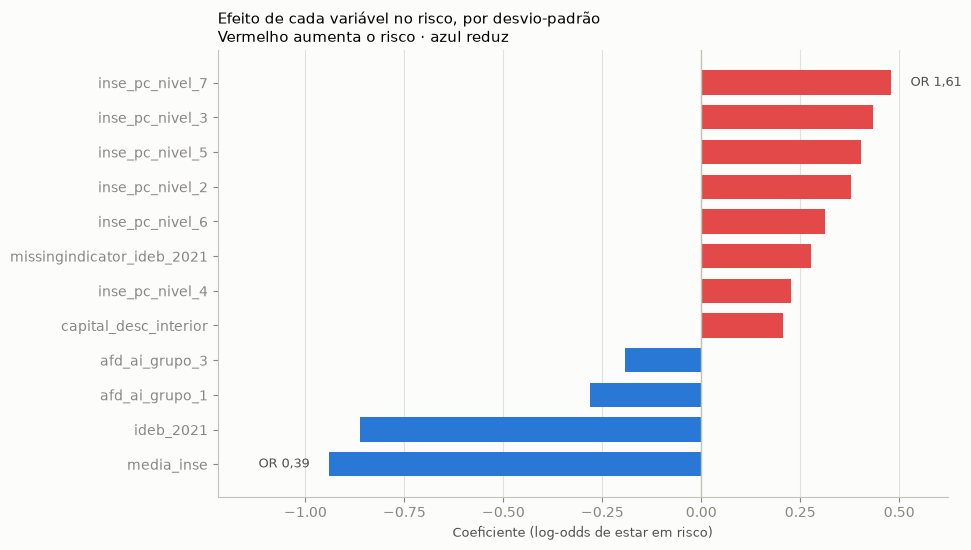

In [18]:
principais = sem_uf.sort_values("magnitude", ascending=False).head(12).sort_values("coeficiente")

fig, eixo = plt.subplots(figsize=(9.8, 5.6))
eixo.barh(principais.index, principais["coeficiente"],
          color=[SERIE[0] if v < 0 else NEGATIVO for v in principais["coeficiente"]], height=0.7)
eixo.axvline(0, color=EIXO, linewidth=1)

for nome in (principais.index[0], principais.index[-1]):
    valor = principais.loc[nome, "coeficiente"]
    razao = principais.loc[nome, "odds_ratio_risco"]
    eixo.text(valor + (0.05 if valor > 0 else -0.05), nome, f"OR {num(razao)}",
              va="center", ha="left" if valor > 0 else "right", fontsize=9, color=TINTA_2)

eixo.set_title("Efeito de cada variável no risco, por desvio-padrão\n"
               "Vermelho aumenta o risco · azul reduz", loc="left")
eixo.set_xlabel("Coeficiente (log-odds de estar em risco)")

# Folga nas pontas: sem ela o rótulo do extremo negativo encosta no nome da variável.
menor, maior = principais["coeficiente"].min(), principais["coeficiente"].max()
eixo.set_xlim(menor * 1.30, maior * 1.30)

limpar(eixo, grade="x")
fig.tight_layout()
salvar(fig, "03_coeficientes", IMAGENS)
plt.show()

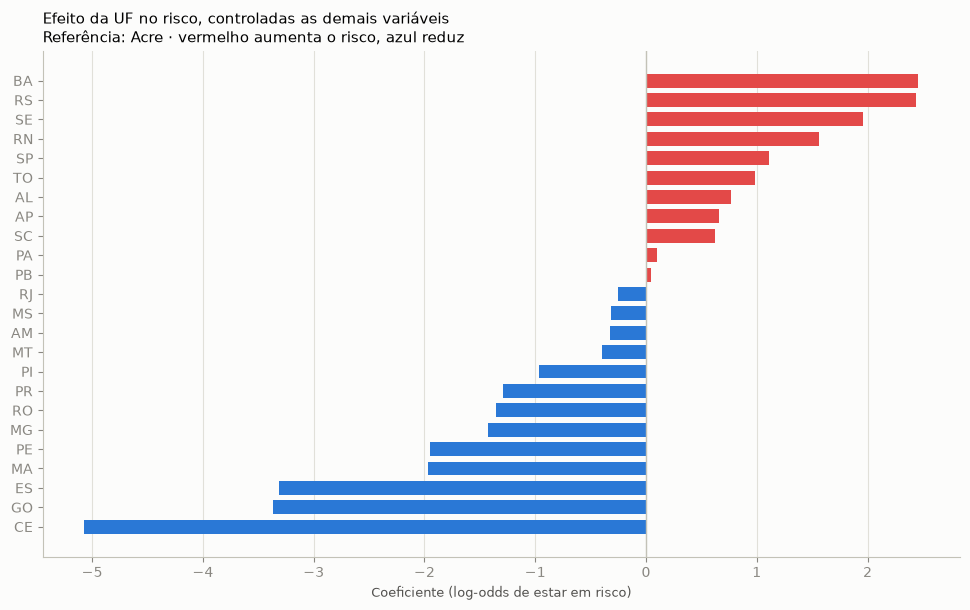

In [19]:
com_uf = tabela_coef[tabela_coef.index.str.startswith("sigla_uf")].sort_values("coeficiente")
com_uf.index = com_uf.index.str.replace("sigla_uf_", "", regex=False)

fig, eixo = plt.subplots(figsize=(9.8, 6.2))
eixo.barh(com_uf.index, com_uf["coeficiente"],
          color=[SERIE[0] if v < 0 else NEGATIVO for v in com_uf["coeficiente"]], height=0.72)
eixo.axvline(0, color=EIXO, linewidth=1)

menor = com_uf["coeficiente"].idxmin()
eixo.text(com_uf.loc[menor, "coeficiente"] + 0.08, menor,
          f"{menor}: OR {num(com_uf.loc[menor, 'odds_ratio_risco'])}",
          va="center", ha="left", fontsize=10, fontweight="bold", color=SERIE[0])

eixo.set_title("Efeito da UF no risco, controladas as demais variáveis\n"
               "Referência: Acre · vermelho aumenta o risco, azul reduz", loc="left")
eixo.set_xlabel("Coeficiente (log-odds de estar em risco)")
limpar(eixo, grade="x")
fig.tight_layout()
salvar(fig, "03_coeficientes_uf", IMAGENS)
plt.show()

In [20]:
importancia = permutation_importance(
    modelo_final, X, y, scoring="average_precision", n_repeats=5,
    random_state=SEMENTE, n_jobs=-1)

pd.DataFrame({
    "queda_no_pr_auc": importancia.importances_mean,
    "desvio": importancia.importances_std,
}, index=X.columns).sort_values("queda_no_pr_auc", ascending=False).head(10).round(5)

,queda_no_pr_auc,desvio
sigla_uf,0.34503,0.00349
media_inse,0.13739,0.00486
ideb_2021,0.10283,0.00501
inse_pc_nivel_3,0.02575,0.00314
inse_pc_nivel_7,0.02241,0.00403
inse_pc_nivel_2,0.02059,0.00219
inse_pc_nivel_5,0.01909,0.00212
inse_pc_nivel_6,0.01116,0.00136
afd_ai_grupo_1,0.00854,0.00245
inse_pc_nivel_4,0.00745,0.00175


Background dataset has 5448 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=5448 when initializing the masker.


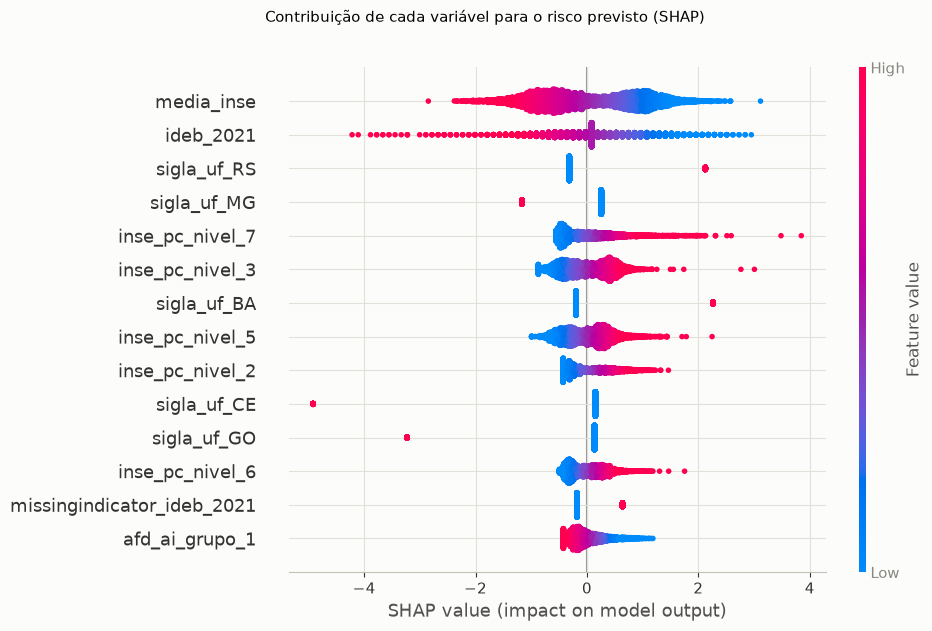

In [21]:
import shap

matriz = modelo_final.named_steps["preprocessamento"].transform(X)
explicador = shap.LinearExplainer(modelo_final.named_steps["modelo"], matriz)
valores_shap = explicador.shap_values(matriz)

np.random.seed(SEMENTE)  # o beeswarm sorteia o deslocamento vertical dos pontos
shap.summary_plot(valores_shap, matriz, feature_names=nomes,
                  max_display=14, show=False, plot_size=(9.8, 6.2))
fig = plt.gcf()
fig.suptitle("Contribuição de cada variável para o risco previsto (SHAP)", fontsize=11, y=1.01)
fig.tight_layout()
salvar(fig, "03_shap_summary", IMAGENS)
plt.show()

In [22]:
pd.Series(np.abs(valores_shap).mean(axis=0), index=nomes) \
  .sort_values(ascending=False).head(12).round(4).rename("SHAP médio absoluto").to_frame()

,SHAP médio absoluto
media_inse,0.8163
ideb_2021,0.6635
sigla_uf_RS,0.4683
sigla_uf_MG,0.3955
inse_pc_nivel_7,0.3881
inse_pc_nivel_3,0.3761
sigla_uf_BA,0.3509
inse_pc_nivel_5,0.3404
inse_pc_nivel_2,0.3260
sigla_uf_CE,0.3130


As três lentes convergem no mesmo conjunto de fatores — o desempenho pregresso do município
(IDEB de 2021), o nível socioeconômico e a unidade federativa dominam, e a formação docente e o
tamanho de turma aparecem logo abaixo, na direção teoricamente esperada.

A leitura detalhada, em pontos percentuais de risco e traduzida para decisão de política, está
no [notebook 04](04_aplicacao_estrategica.ipynb).

---

## 10. Limitações

1. **A premissa do município.** O modelo trata a alfabetização do aluno como dada pelo contexto
   municipal. Nenhuma característica individual da criança entra — duas crianças do mesmo
   município recebem a mesma predição.
2. **Um único ciclo.** Modelamos 2024. Não há teste de generalização para um ciclo futuro, e a
   estabilidade do ranking entre ciclos não pode ser verificada com este recorte.
3. **O corte de 50% é uma escolha.** Absoluto e comunicável, mas uma escolha — municípios com
   49% e 51% são tratados como categorias diferentes, embora sejam praticamente iguais.
4. **Sem variáveis de política educacional.** O efeito da UF é grande e o modelo não consegue
   explicá-lo, só medi-lo.
5. **Cobertura territorial incompleta:** 25 das 27 UFs. O Distrito Federal não tem rede
   municipal e Roraima está ausente do arquivo do INEP.
6. **Associações condicionais, não efeitos causais.**

---

## Conclusão

| | Valor |
|---|---:|
| Municípios modelados (ciclo 2024) | 5.448 |
| Classe de risco (taxa < 50%) | 27,3% |
| ROC-AUC no teste | **0,879** |
| PR-AUC no teste (prevalência 0,272) | **0,692** |
| Gap treino-validação | 0,007 |

A **Regressão Logística** foi escolhida entre oito algoritmos por ter o melhor ROC-AUC e o menor
sobreajuste, empatando tecnicamente no PR-AUC com o Gradient Boosting, que sobreajusta nove
vezes mais. A saída é **calibrada** — a probabilidade pode ser lida como chance real de risco —
e o limiar de decisão é tratado como escolha de política, com a régua de cobertura explícita.

**Próximo passo:** [`04_aplicacao_estrategica.ipynb`](04_aplicacao_estrategica.ipynb) — as cinco
perguntas de negócio, todas respondidas a partir deste mesmo classificador.